In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table, unique, join

In [19]:
def Mg_BPRP_RUWE(data_file):
    
    with fits.open(data_file) as hdul:
        data = hdul[1].data
    
    # Select members
    mask = data["MemBool"] == 1
    
    bp = data["GAIAEDR3_BP"][mask]
    rp = data["GAIAEDR3_RP"][mask]
    G  = data["GAIAEDR3_G_CORRECTED"][mask]
    ruwe = data["GAIAEDR3_RUWE"][mask]
    dist = data["dist"][mask]
    
    # Make sure all the data is good, no "NaN" or stuff like that
    cleandata = (
        np.isfinite(bp) &
        np.isfinite(rp) &
        np.isfinite(G) &
        np.isfinite(ruwe) &
        np.isfinite(dist) &
        (dist > 0)
    )
    
    bp = bp[cleandata]
    rp = rp[cleandata]
    G = G[cleandata]
    ruwe = ruwe[cleandata]
    dist = dist[cleandata]
    
    MG = G - 5 * np.log10(dist) + 5
    color = bp - rp
    
    # Sort by RUWE so higher RUWE stars appear on top
    order = np.argsort(ruwe)
    
    color = color[order]
    MG = MG[order]
    ruwe = ruwe[order]
    
    # Plot
    plt.scatter(color, MG, c=ruwe, s=10)
    plt.gca().invert_yaxis()
    
    cbar = plt.colorbar()
    cbar.set_label("RUWE")
    
    plt.xlabel("BP - RP")
    plt.ylabel("M_G")
    plt.title("M_g vs BP-RP colored by RUWE")
    plt.show()

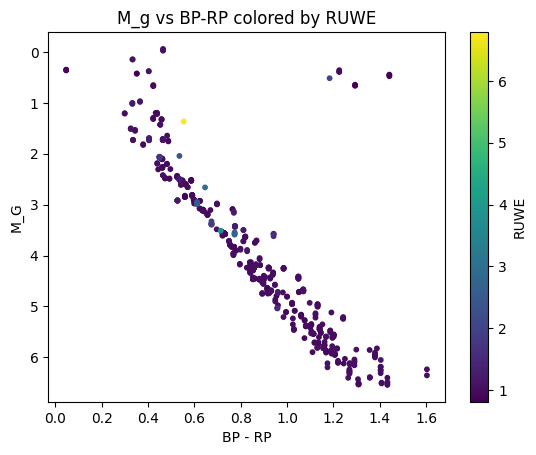

In [23]:
Mg_BPRP_RUWE("rcat_ngc6866_v0.fits")